# Logistic Regression Feature Group Comparison

This notebook conducts a rigorous control experiment to determine which subset of signal characteristics is most informative for pulsar detection.

We segment the 12 available predictors into two distinct groups based on their physical origins: Profile features (describing the signal's shape) and DM-SNR features (describing dispersion delay attributes). By maintaining identical validation protocols and pipeline structures across all tests, we can directly attribute performance variations to the underlying information content of the feature groups.

### Step 1: Environment and Data Setup
We load libraries, establish the same `PredefinedSplit` setup from our baseline, and guarantee experimental continuity.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load data
df_train = pd.read_csv('../outputs/processed_data/train_engineered.csv')
df_dev = pd.read_csv('../outputs/processed_data/dev_engineered.csv')
df_test = pd.read_csv('../outputs/processed_data/test_engineered.csv')

target_col = 'class'
X_train_raw = df_train.drop(columns=[target_col])
y_train_raw = df_train[target_col]
X_dev_raw = df_dev.drop(columns=[target_col])
y_dev_raw = df_dev[target_col]
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

# Predefined Split setup for validation integrity
X_train_dev = pd.concat([X_train_raw, X_dev_raw], axis=0, ignore_index=True)
y_train_dev = pd.concat([y_train_raw, y_dev_raw], axis=0, ignore_index=True)

test_fold = np.zeros(X_train_dev.shape[0])
test_fold[:X_train_raw.shape[0]] = -1
ps = PredefinedSplit(test_fold=test_fold)

### Step 2: Feature Group Identification
We parse the column names dynamically to separate Profile-derived statistics from DM-SNR-derived statistics. We define three discrete experimental groups to be evaluated.

In [2]:
profile_cols = [col for col in X_train_raw.columns if col.lower().startswith('profile_')]
dm_cols = [col for col in X_train_raw.columns if col.lower().startswith('dm_')]

feature_groups = {
    "All Features": list(X_train_raw.columns),
    "Profile Only": profile_cols,
    "DM-SNR Only": dm_cols
}

print(f"Profile Columns ({len(profile_cols)} predictors): {profile_cols}\n")
print(f"DM-SNR Columns ({len(dm_cols)} predictors): {dm_cols}")

Profile Columns (6 predictors): ['Profile_mean', 'Profile_stdev', 'Profile_skewness', 'Profile_kurtosis', 'profile_cv', 'profile_shape_score']

DM-SNR Columns (6 predictors): ['DM_mean', 'DM_stdev', 'DM_skewness', 'DM_kurtosis', 'DM_cv', 'DM_shape_score']


### Step 3: Experimental Loop Execution
We iterate through the defined feature groups. For each group, we slice the dataset accordingly, initialize a fresh `Pipeline`, train the model, and record the probabilities. This ensures all models are evaluated on a completely level playing field.

In [3]:
results = []
all_group_predictions = {} # Dictionary to store probabilities for comparative plotting later

for group_name, cols in feature_groups.items():
    print(f"Executing pipeline for: {group_name} ...")
    
    # Subset features specific to this experiment block
    X_td_sub = X_train_dev[cols]
    X_test_sub = X_test[cols]
    
    pipeline_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(random_state=42, max_iter=1000, C=1.0))
    ])
    
    grid_lr = GridSearchCV(
        estimator=pipeline_lr,
        param_grid={},
        cv=ps,
        scoring='average_precision',
        refit=True,
    )
    
    # Train model on this subset
    grid_lr.fit(X_td_sub, y_train_dev)
    
    # Gather inference metrics on the test set
    y_pred = grid_lr.predict(X_test_sub)
    y_proba = grid_lr.predict_proba(X_test_sub)[:, 1]
    
    all_group_predictions[group_name] = {"y_pred": y_pred, "y_proba": y_proba}
    
    # Log the required evaluation metrics
    metrics = {
        'Feature Group': group_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba)
    }
    results.append(metrics)

print("\n=== Comparative Results Summary ===")
results_df = pd.DataFrame(results)
display(results_df.round(4))

Executing pipeline for: All Features ...
Executing pipeline for: Profile Only ...
Executing pipeline for: DM-SNR Only ...

=== Comparative Results Summary ===


,Feature Group,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,All Features,0.9803,0.9617,0.8171,0.8835,0.9737,0.9072
1,Profile Only,0.9758,0.9458,0.7805,0.8552,0.9718,0.9103
2,DM-SNR Only,0.9330,0.7619,0.3902,0.5161,0.8934,0.6195


### Step 4: Overlapping ROC Curve Visualization
To provide a clear visual comparison of the discriminative power across feature subsets, we map their respective ROC curves onto a single graph.

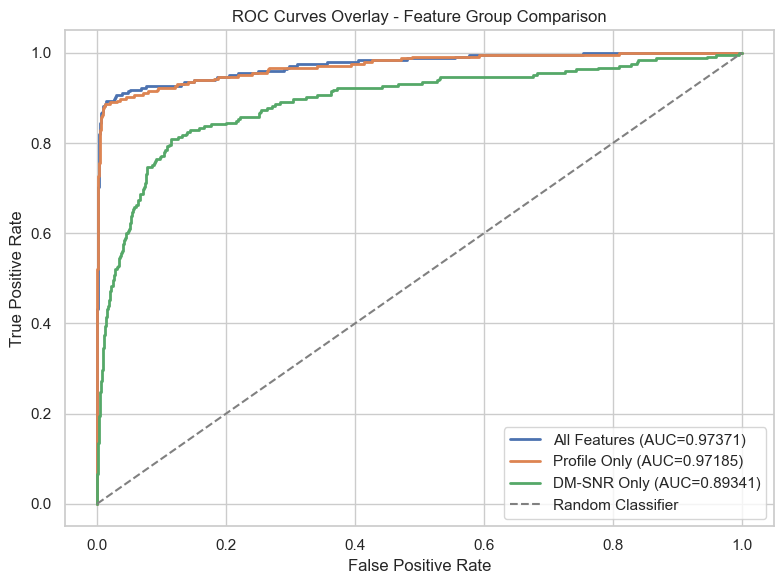

In [4]:
plt.figure(figsize=(8, 6))

for group_name, pred_dict in all_group_predictions.items():
    y_proba = pred_dict["y_proba"]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{group_name} (AUC={roc_auc:.5f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Overlay - Feature Group Comparison")
plt.legend()
plt.tight_layout()
plt.show()

### Step 5: Overlapping Precision-Recall Curve Visualization
Crucially for our imbalance research question, this overlapping PR curve plot clearly demonstrates which feature subset best isolates the minority class without sacrificing precision.

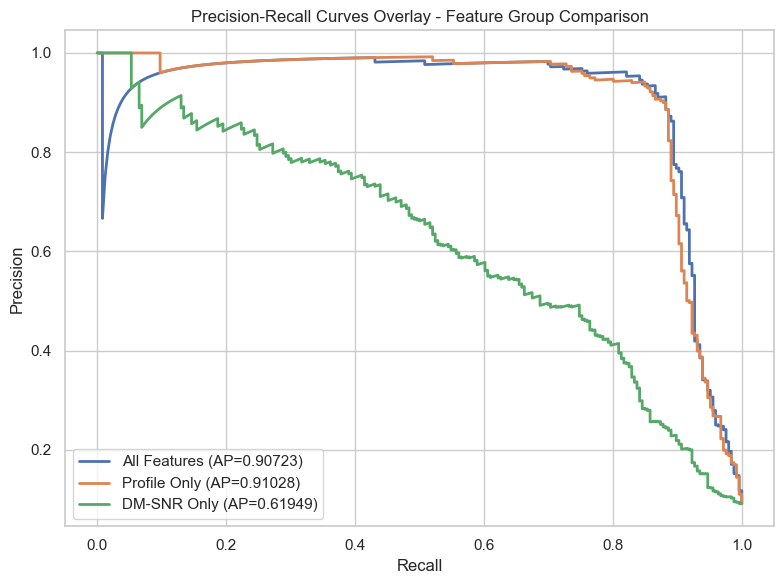

In [5]:
plt.figure(figsize=(8, 6))

for group_name, pred_dict in all_group_predictions.items():
    y_proba = pred_dict["y_proba"]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall_vals, precision_vals, label=f"{group_name} (AP={ap:.5f})", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Overlay - Feature Group Comparison")
plt.legend()
plt.tight_layout()
plt.show()